In [1]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam

from astropy.coordinates import SkyCoord
import astropy.units as u

In [2]:
# ============================================================
# Paths & device
# ============================================================

data_dir = r"C:/Raj_Stuff/Coding/VScode/Workspaces/Astro-ML/Data/XMM-Gaia-Cross-Matched Data Separate"
model_dir = r"C:/Raj_Stuff/Coding/VScode/Workspaces/Astro-ML/Models"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ============================================================
# Load data
# ============================================================

xmm_df = pd.read_parquet(f"{data_dir}/xmm_raw.parquet")
gaia_df = pd.read_parquet(f"{data_dir}/gaia_raw.parquet")
matched_df = pd.read_parquet(f"{data_dir}/cross_matched_raw.parquet")

Using device: cuda


In [3]:
# ============================================================
# Feature columns
# ============================================================

gaia_cols = [
    "gaia_e_RA_ICRS", "gaia_e_DE_ICRS",
    "gaia_pmRA", "gaia_e_pmRA",
    "gaia_pmDE", "gaia_e_pmDE",
    "gaia_Plx", "gaia_e_Plx",
]

xmm_cols = [
    "SC_POSERR",
    "SC_DET_ML",
    "N_DETECTIONS",
    "CONFUSED",
    "HIGH_BACKGROUND",
    "No/Nx",
]

In [4]:
# In xmm_df
xmm_df["xmm_key"] = list(zip(xmm_df["DETID"], xmm_df["SRCID"]))

# In matched_df
matched_df["xmm_key"] = list(zip(matched_df["xmm_DETID"], matched_df["xmm_SRCID"]))


In [5]:
gaia_source_to_index = {
    src: idx for idx, src in gaia_df["gaia_Source"].items()
}
assert gaia_df["gaia_Source"].is_unique
assert matched_df["gaia_Source"].isin(gaia_df["gaia_Source"]).all()
assert matched_df["xmm_key"].isin(xmm_df["xmm_key"]).all()


In [6]:
xmmkey_to_gaia = dict(zip(matched_df["xmm_key"], matched_df["gaia_Source"]))

In [7]:
valid_xmm_mask = xmm_df["xmm_key"].isin(xmmkey_to_gaia)
valid_xmm_indices = xmm_df.index[valid_xmm_mask].to_numpy()


In [8]:
# ============================================================
# Load encoders
# ============================================================

from src.inference.encoder import xmm_encoder, gaia_encoder

xmm_encoder_path = f"{model_dir}/encoders/1e-3/simclr_xmm_3_frozen.pth"
gaia_encoder_path = f"{model_dir}/encoders/1e-3/simclr_gaia_3_frozen.pth"

xmm_enc = xmm_encoder(xmm_encoder_path).to(device)
gaia_enc = gaia_encoder(gaia_encoder_path).to(device)

xmm_enc.eval()
gaia_enc.eval()

for p in xmm_enc.parameters():
    p.requires_grad = False
for p in gaia_enc.parameters():
    p.requires_grad = False

In [9]:
# ============================================================
# Candidate generation
# ============================================================

def get_provisional_candidates(xmm_df, gaia_df, k_sigma=3.0):
    xmm_coords = SkyCoord(
        ra=xmm_df["SC_RA"].values * u.deg,
        dec=xmm_df["SC_DEC"].values * u.deg,
    )
    gaia_coords = SkyCoord(
        ra=gaia_df["gaia_RA_ICRS"].values * u.deg,
        dec=gaia_df["gaia_DE_ICRS"].values * u.deg,
    )

    max_radius = k_sigma * xmm_df["SC_POSERR"].max() * u.arcsec
    ix, ig, sep2d, _ = gaia_coords.search_around_sky(xmm_coords, max_radius)

    mask = sep2d.arcsec <= (k_sigma * xmm_df["SC_POSERR"].iloc[ix].values)
    return ix[mask], ig[mask], sep2d[mask].arcsec


ix, ig, seps = get_provisional_candidates(xmm_df, gaia_df)

In [10]:
# # ============================================================
# # Candidate preparation
# # ============================================================

# def prepare_candidate_matrix(xmm_idx):
#     mask = ix == xmm_idx
#     gaia_indices = ig[mask]

#     if len(gaia_indices) == 0:
#         return None

#     xmm_feat = torch.tensor(
#         xmm_df.iloc[xmm_idx][xmm_cols].values,
#         dtype=torch.float32,
#         device=device,
#     )

#     gaia_feat = torch.tensor(
#         gaia_df.iloc[gaia_indices][gaia_cols].values,
#         dtype=torch.float32,
#         device=device,
#     )

#     sep = torch.tensor(seps[mask], dtype=torch.float32, device=device)
#     poserr = xmm_df.iloc[xmm_idx]["SC_POSERR"]

#     return xmm_feat, gaia_feat, sep, poserr, gaia_indices

In [11]:
def prepare_candidate_matrix(xmm_idx):
    mask = ix == xmm_idx
    gaia_indices = ig[mask]

    if len(gaia_indices) == 0:
        return None

    # ---- XMM features (force numeric) ----
    xmm_vals = (
        xmm_df.iloc[xmm_idx][xmm_cols]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0.0)
        .to_numpy(dtype=np.float32)
    )

    xmm_feat = torch.from_numpy(xmm_vals).to(device)

    # ---- Gaia features (already numeric, but be safe) ----
    gaia_vals = (
        gaia_df.iloc[gaia_indices][gaia_cols]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0.0)
        .to_numpy(dtype=np.float32)
    )

    gaia_feat = torch.from_numpy(gaia_vals).to(device)

    sep = torch.tensor(seps[mask], dtype=torch.float32, device=device)
    poserr = float(xmm_df.iloc[xmm_idx]["SC_POSERR"])

    return xmm_feat, gaia_feat, sep, poserr, gaia_indices


In [12]:
print(xmm_df[xmm_cols].dtypes)


SC_POSERR          float32
SC_DET_ML          float32
N_DETECTIONS         int16
CONFUSED              bool
HIGH_BACKGROUND       bool
No/Nx              float64
dtype: object


In [13]:
# ============================================================
# Matcher model
# ============================================================

class XMMGaiaMatcher(nn.Module):
    def __init__(self, embed_dim=64):
        super().__init__()
        self.W = nn.Parameter(torch.randn(embed_dim, embed_dim) * 0.02)
        self.null_bias = nn.Parameter(torch.zeros(1))

    def forward(self, z_xmm, z_gaia, sep_arcsec, xmm_poserr, alpha=1.0):
        semantic = z_gaia @ self.W @ z_xmm              # (K,)
        geom_penalty = alpha * (sep_arcsec / xmm_poserr) ** 2
        logits = semantic - geom_penalty
        return torch.cat([logits, self.null_bias])     # (K+1,)


matcher = XMMGaiaMatcher(embed_dim=64).to(device)
optimizer = Adam(matcher.parameters(), lr=1e-3)

In [14]:
# # ============================================================
# # Training loop with batching
# # ============================================================

# def train_epoch(batch_size=32):
#     matcher.train()
#     total_loss = 0.0
#     correct = 0
#     total_valid = 0

#     indices = valid_xmm_indices.copy()
#     np.random.shuffle(indices)

#     for start in tqdm(range(0, len(indices), batch_size), desc="Training"):
#         batch_idx = indices[start : start + batch_size]

#         optimizer.zero_grad()
#         batch_loss = 0.0
#         batch_valid = 0

#         for i in batch_idx:
#             prepared = prepare_candidate_matrix(i)
#             if prepared is None:
#                 continue

#             xmm_f, gaia_f, sep, err, c_indices = prepared

#             with torch.no_grad():
#                 z_xmm = xmm_enc(xmm_f.unsqueeze(0)).squeeze(0)
#                 z_gaia = gaia_enc(gaia_f)

#             logits = matcher(z_xmm, z_gaia, sep, err)

#             xmm_key = xmm_df.iloc[i]["xmm_key"]
            
#             true_gaia_source = matched_df.loc[
#                 matched_df["xmm_key"] == xmm_key, "gaia_Source"
#             ].values

#             candidate_sources = gaia_df.iloc[c_indices]["gaia_Source"].values

#             match = np.where(candidate_sources == true_gaia_source)[0]
#             if len(match) > 0:
#                 target = torch.tensor(match[0], device=device)
#             else:
#                 target = torch.tensor(len(c_indices), device=device)  # NULL


#             loss = F.cross_entropy(
#                 logits.unsqueeze(0), target.unsqueeze(0)
#             )

#             batch_loss += loss
#             batch_valid += 1
#             total_valid += 1

#             if torch.argmax(logits) == target:
#                 correct += 1

#         if batch_valid > 0:
#             (batch_loss / batch_valid).backward()
#             optimizer.step()
#             total_loss += batch_loss.item()

#     return (
#         total_loss / max(total_valid, 1),
#         correct / max(total_valid, 1),
#     )

In [15]:
def train_epoch(batch_size=32):
    matcher.train()
    total_loss = 0.0
    correct = 0
    total_valid = 0

    indices = valid_xmm_indices.copy()
    np.random.shuffle(indices)

    for start in tqdm(range(0, len(indices), batch_size), desc="Training"):
        batch_idx = indices[start : start + batch_size]

        optimizer.zero_grad()
        batch_loss = 0.0
        batch_valid = 0

        for i in batch_idx:
            prepared = prepare_candidate_matrix(i)
            if prepared is None:
                continue

            xmm_f, gaia_f, sep, err, c_indices = prepared

            with torch.no_grad():
                z_xmm = xmm_enc(xmm_f.unsqueeze(0)).squeeze(0)
                z_gaia = gaia_enc(gaia_f)

            logits = matcher(z_xmm, z_gaia, sep, err)
            # logits shape should be (num_candidates + 1) if matcher includes NULL

            # ---- Supervision ----
            xmm_key = xmm_df.iloc[i]["xmm_key"]

            true_rows = matched_df.loc[
                matched_df["xmm_key"] == xmm_key, "gaia_Source"
            ].values

            if len(true_rows) == 0:
                continue  # no supervision available

            true_gaia_source = true_rows[0]

            candidate_sources = gaia_df.iloc[c_indices]["gaia_Source"].values

            match = np.where(candidate_sources == true_gaia_source)[0]

            if len(match) > 0:
                target_idx = match[0]
            else:
                # TRUE counterpart not in geometric candidate list
                target_idx = len(c_indices)  # NULL class index

            target = torch.tensor(target_idx, device=device)

            loss = F.cross_entropy(
                logits.unsqueeze(0),
                target.unsqueeze(0)
            )

            batch_loss += loss
            batch_valid += 1
            total_valid += 1

            if torch.argmax(logits) == target:
                correct += 1

        if batch_valid > 0:
            (batch_loss / batch_valid).backward()
            optimizer.step()
            total_loss += batch_loss.item()

    return (
        total_loss / max(total_valid, 1),
        correct / max(total_valid, 1),
    )


In [16]:
# ============================================================
# Run training
# ============================================================

num_epochs = 25

for epoch in range(num_epochs):
    loss, acc = train_epoch(batch_size=32)
    print(f"Epoch {epoch+1:02d} | Loss: {loss:.4f} | Acc: {acc:.4f}")

Training:   0%|          | 0/456 [00:00<?, ?it/s]

Training: 100%|██████████| 456/456 [05:53<00:00,  1.29it/s]


Epoch 01 | Loss: 1.3286 | Acc: 0.4050


Training: 100%|██████████| 456/456 [06:11<00:00,  1.23it/s]


Epoch 02 | Loss: 0.8513 | Acc: 0.6717


...

Epoch 23 | Loss: 0.0468 | Acc: 0.9846


Training: 100%|██████████| 456/456 [01:40<00:00,  4.53it/s]


Epoch 24 | Loss: 0.0434 | Acc: 0.9856


Training: 100%|██████████| 456/456 [01:29<00:00,  5.12it/s]

Epoch 25 | Loss: 0.0406 | Acc: 0.9865


# Model Evaluation

fetch probs from model

In [17]:
def evaluate_model():
    matcher.eval()
    
    y_true = []
    y_score = []

    with torch.no_grad():
        for i in valid_xmm_indices:
            prepared = prepare_candidate_matrix(i)
            if prepared is None:
                continue

            xmm_f, gaia_f, sep, err, c_indices = prepared

            z_xmm = xmm_enc(xmm_f.unsqueeze(0)).squeeze(0)
            z_gaia = gaia_enc(gaia_f)

            logits = matcher(z_xmm, z_gaia, sep, err)
            probs = torch.softmax(logits, dim=0)

            xmm_key = xmm_df.iloc[i]["xmm_key"]
            true_rows = matched_df.loc[
                matched_df["xmm_key"] == xmm_key, "gaia_Source"
            ].values

            if len(true_rows) == 0:
                continue

            true_source = true_rows[0]
            candidate_sources = gaia_df.iloc[c_indices]["gaia_Source"].values

            for j, src in enumerate(candidate_sources):
                y_score.append(probs[j].item())
                y_true.append(1 if src == true_source else 0)

    return np.array(y_true), np.array(y_score)


ROC Curve

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_true, y_score = evaluate_model()

fpr_ml, tpr_ml, _ = roc_curve(y_true, y_score)
auc_ml = auc(fpr_ml, tpr_ml)

# Bayesian
fpr_bayes, tpr_bayes, _ = roc_curve(y_true, bayes_probs)
auc_bayes = auc(fpr_bayes, tpr_bayes)

plt.figure()
plt.plot(fpr_ml, tpr_ml, label=f"ML (AUC={auc_ml:.3f})")
plt.plot(fpr_bayes, tpr_bayes, label=f"Bayesian (AUC={auc_bayes:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.title("ROC Curve: ML vs Bayesian")
plt.show()


Precision–Recall Curve

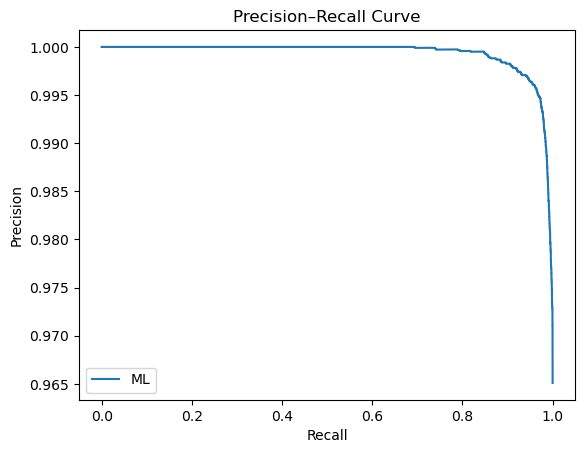

In [19]:
from sklearn.metrics import precision_recall_curve

precision_ml, recall_ml, _ = precision_recall_curve(y_true, y_score)

plt.figure()
plt.plot(recall_ml, precision_ml, label="ML")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.show()


Probability vs Separation Plot (Astrophysical Sanity Check)

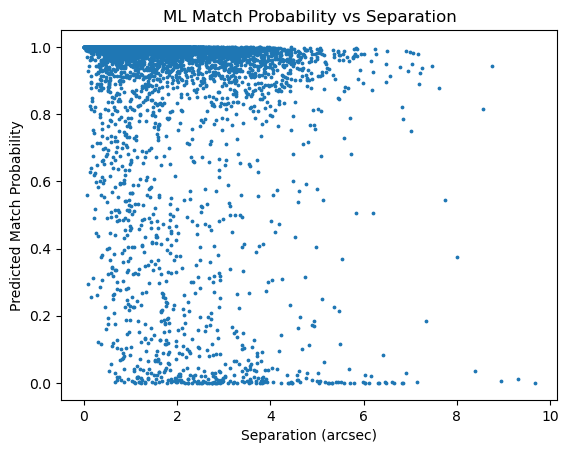

In [20]:
separations = []
probabilities = []

with torch.no_grad():
    for i in valid_xmm_indices:
        prepared = prepare_candidate_matrix(i)
        if prepared is None:
            continue

        xmm_f, gaia_f, sep, err, c_indices = prepared

        z_xmm = xmm_enc(xmm_f.unsqueeze(0)).squeeze(0)
        z_gaia = gaia_enc(gaia_f)

        logits = matcher(z_xmm, z_gaia, sep, err)
        probs = torch.softmax(logits, dim=0)

        for j in range(len(sep)):
            separations.append(sep[j].item())
            probabilities.append(probs[j].item())

plt.figure()
plt.scatter(separations, probabilities, s=3)
plt.xlabel("Separation (arcsec)")
plt.ylabel("Predicted Match Probability")
plt.title("ML Match Probability vs Separation")
plt.show()


### Reliability–Completeness Curve (Most Astronomical)

For a probability threshold 
𝑇
T:

Completeness = fraction of true matches recovered

Reliability = fraction of predicted matches that are true

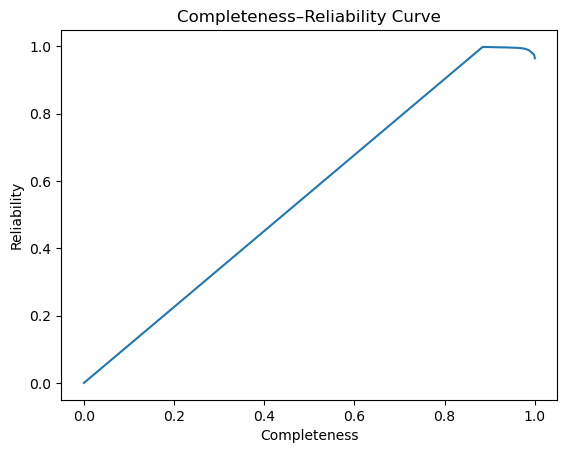

In [21]:
thresholds = np.linspace(0, 1, 50)
completeness = []
reliability = []

for t in thresholds:
    predicted = y_score >= t
    
    tp = np.sum((predicted == 1) & (y_true == 1))
    fp = np.sum((predicted == 1) & (y_true == 0))
    fn = np.sum((predicted == 0) & (y_true == 1))
    
    comp = tp / (tp + fn + 1e-8)
    rel = tp / (tp + fp + 1e-8)
    
    completeness.append(comp)
    reliability.append(rel)

plt.figure()
plt.plot(completeness, reliability)
plt.xlabel("Completeness")
plt.ylabel("Reliability")
plt.title("Completeness–Reliability Curve")
plt.show()


# Bayesian Calculations

In [22]:
# Background Density

def estimate_global_density(xmm_df, gaia_df):
    ra_min, ra_max = xmm_df["SC_RA"].min(), xmm_df["SC_RA"].max()
    dec_min, dec_max = xmm_df["SC_DEC"].min(), xmm_df["SC_DEC"].max()

    area_deg2 = (ra_max - ra_min) * (dec_max - dec_min) * \
                np.cos(np.deg2rad((dec_min + dec_max)/2))

    area_arcsec2 = area_deg2 * (3600**2)

    return len(gaia_df) / area_arcsec2

rho = estimate_global_density(xmm_df, gaia_df)


In [23]:
def compute_bayes_for_source(sep_arcsec, xmm_sigma, gaia_sigma_ra, gaia_sigma_dec, rho, prior=0.1):

    gaia_sigma = np.sqrt(gaia_sigma_ra**2 + gaia_sigma_dec**2)
    sigma2 = xmm_sigma**2 + gaia_sigma**2

    L = (1 / (2 * np.pi * sigma2)) * \
        np.exp(-(sep_arcsec**2) / (2 * sigma2))

    L_null = rho

    numerator = prior * L
    denominator = prior * np.sum(L) + (1 - prior) * L_null

    P = numerator / denominator
    P_null = (1 - prior) * L_null / denominator

    return P, P_null


In [24]:
def evaluate_bayesian(prior=0.1):

    y_true = []
    y_score = []

    for i in valid_xmm_indices:
        prepared = prepare_candidate_matrix(i)
        if prepared is None:
            continue

        xmm_f, gaia_f, sep, err, c_indices = prepared

        sep_np = sep.cpu().numpy()
        xmm_sigma = err

        gaia_subset = gaia_df.iloc[c_indices]

        gaia_sigma_ra = gaia_subset["gaia_e_RA_ICRS"].values
        gaia_sigma_dec = gaia_subset["gaia_e_DE_ICRS"].values

        P, P_null = compute_bayes_for_source(
            sep_np,
            xmm_sigma,
            gaia_sigma_ra,
            gaia_sigma_dec,
            rho,
            prior
        )

        xmm_key = xmm_df.iloc[i]["xmm_key"]
        true_rows = matched_df.loc[
            matched_df["xmm_key"] == xmm_key, "gaia_Source"
        ].values

        if len(true_rows) == 0:
            continue

        true_source = true_rows[0]
        candidate_sources = gaia_subset["gaia_Source"].values

        for j, src in enumerate(candidate_sources):
            y_score.append(P[j])
            y_true.append(1 if src == true_source else 0)

    return np.array(y_true), np.array(y_score)


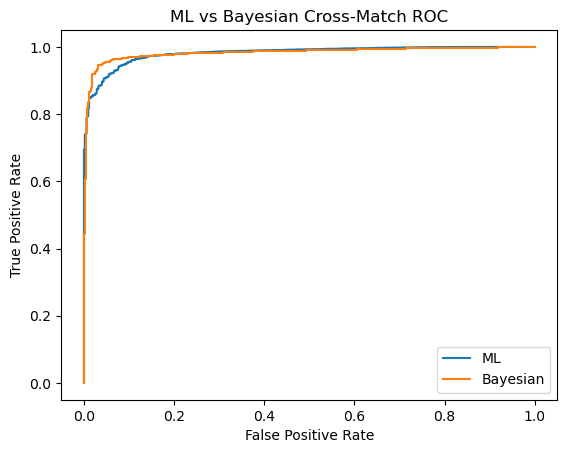

In [25]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

y_true_ml, y_score_ml = evaluate_model()
y_true_b, y_score_b = evaluate_bayesian(prior=0.1)

fpr_ml, tpr_ml, _ = roc_curve(y_true_ml, y_score_ml)
fpr_b, tpr_b, _ = roc_curve(y_true_b, y_score_b)

plt.figure()
plt.plot(fpr_ml, tpr_ml, label="ML")
plt.plot(fpr_b, tpr_b, label="Bayesian")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.title("ML vs Bayesian Cross-Match ROC")
plt.show()
